In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_universo  = pd.read_csv('df_universo.csv')


In [2]:
df_universo.periodo.unique()

array(['period_5', 'period_6', 'period_4', 'period_3', 'period_2',
       'period_1'], dtype=object)

In [3]:
df_universo['target'].value_counts() # here

target
0    464075
1     47171
5      8489
4      6893
2      5929
3      3386
Name: count, dtype: int64

In [4]:
print(f"Cantidad de variables: {len(df_universo.columns)}")

Cantidad de variables: 84


**ANÁLISIS DE NULOS**

In [5]:
# Calcula el CONTEO (números enteros) de nulos por columna
# .sum() trata True como 1 y False como 0
nulos_conteo = df_universo.isnull().sum().sort_values(ascending=False)

# Filtra la Serie para quedarte solo con las columnas que tienen nulos
nulos_enteros = nulos_conteo[nulos_conteo > 0]

# Imprime el resultado
print(nulos_enteros)

DB_SAL_CUE_std_3m_ahorros                 19510
DB_SAL_CUE_cv_3m_ahorros                  19510
DB_SAL_CUE_ratio_ahorros_otros            17359
DB_SAL_CUE_prop_ahorros_total             17359
DB_SAL_CUE_4_meses_prom_saldo_ahorros     15564
DB_SAL_CUE_5_meses_max_saldo_ahorros      15564
DB_SAL_CUE_5_meses_min_saldo_ahorros      15564
DB_SAL_CUE_5_meses_sum_saldo_ahorros      15564
DB_SAL_CUE_3_meses_prom_saldo_ahorros     15564
DB_SAL_CUE_4_meses_max_saldo_ahorros      15564
DB_SAL_CUE_4_meses_min_saldo_ahorros      15564
DB_SAL_CUE_4_meses_sum_saldo_ahorros      15564
DB_SAL_CUE_5_meses_prom_saldo_ahorros     15564
DB_SAL_CUE_2_meses_min_saldo_ahorros      15564
DB_SAL_CUE_2_meses_max_saldo_ahorros      15564
DB_SAL_CUE_2_meses_sum_saldo_ahorros      15564
DB_SAL_CUE_7_meses_prom_saldo_ahorros     15564
DB_SAL_CUE_6_meses_sum_saldo_ahorros      15564
DB_SAL_CUE_6_meses_max_saldo_ahorros      15564
DB_SAL_CUE_6_meses_min_saldo_ahorros      15564
DB_SAL_CUE_10_meses_sum_saldo_ahorros   

In [6]:
# Calcula los porcentajes de nulos
nulos_porcentaje = (df_universo.isnull().mean() * 100).sort_values(ascending=False)

# Filtra la Serie para quedarte solo con los valores mayores a 0
nulos_mayores_a_cero = nulos_porcentaje[nulos_porcentaje > 0]

# Imprime el resultado
print(nulos_mayores_a_cero)

DB_SAL_CUE_std_3m_ahorros                 3.640312
DB_SAL_CUE_cv_3m_ahorros                  3.640312
DB_SAL_CUE_ratio_ahorros_otros            3.238964
DB_SAL_CUE_prop_ahorros_total             3.238964
DB_SAL_CUE_4_meses_prom_saldo_ahorros     2.904040
DB_SAL_CUE_5_meses_max_saldo_ahorros      2.904040
DB_SAL_CUE_5_meses_min_saldo_ahorros      2.904040
DB_SAL_CUE_5_meses_sum_saldo_ahorros      2.904040
DB_SAL_CUE_3_meses_prom_saldo_ahorros     2.904040
DB_SAL_CUE_4_meses_max_saldo_ahorros      2.904040
DB_SAL_CUE_4_meses_min_saldo_ahorros      2.904040
DB_SAL_CUE_4_meses_sum_saldo_ahorros      2.904040
DB_SAL_CUE_5_meses_prom_saldo_ahorros     2.904040
DB_SAL_CUE_2_meses_min_saldo_ahorros      2.904040
DB_SAL_CUE_2_meses_max_saldo_ahorros      2.904040
DB_SAL_CUE_2_meses_sum_saldo_ahorros      2.904040
DB_SAL_CUE_7_meses_prom_saldo_ahorros     2.904040
DB_SAL_CUE_6_meses_sum_saldo_ahorros      2.904040
DB_SAL_CUE_6_meses_max_saldo_ahorros      2.904040
DB_SAL_CUE_6_meses_min_saldo_ah

In [7]:
# Identificar columnas numéricas con nulos
columnas_con_nulos = nulos_mayores_a_cero.index.tolist()
print(f"Total de columnas con nulos: {len(columnas_con_nulos)}")
print("\nColumnas con nulos:")
for col in columnas_con_nulos:
    print(f"  - {col}: {nulos_mayores_a_cero[col]:.2f}%")

Total de columnas con nulos: 51

Columnas con nulos:
  - DB_SAL_CUE_std_3m_ahorros: 3.64%
  - DB_SAL_CUE_cv_3m_ahorros: 3.64%
  - DB_SAL_CUE_ratio_ahorros_otros: 3.24%
  - DB_SAL_CUE_prop_ahorros_total: 3.24%
  - DB_SAL_CUE_4_meses_prom_saldo_ahorros: 2.90%
  - DB_SAL_CUE_5_meses_max_saldo_ahorros: 2.90%
  - DB_SAL_CUE_5_meses_min_saldo_ahorros: 2.90%
  - DB_SAL_CUE_5_meses_sum_saldo_ahorros: 2.90%
  - DB_SAL_CUE_3_meses_prom_saldo_ahorros: 2.90%
  - DB_SAL_CUE_4_meses_max_saldo_ahorros: 2.90%
  - DB_SAL_CUE_4_meses_min_saldo_ahorros: 2.90%
  - DB_SAL_CUE_4_meses_sum_saldo_ahorros: 2.90%
  - DB_SAL_CUE_5_meses_prom_saldo_ahorros: 2.90%
  - DB_SAL_CUE_2_meses_min_saldo_ahorros: 2.90%
  - DB_SAL_CUE_2_meses_max_saldo_ahorros: 2.90%
  - DB_SAL_CUE_2_meses_sum_saldo_ahorros: 2.90%
  - DB_SAL_CUE_7_meses_prom_saldo_ahorros: 2.90%
  - DB_SAL_CUE_6_meses_sum_saldo_ahorros: 2.90%
  - DB_SAL_CUE_6_meses_max_saldo_ahorros: 2.90%
  - DB_SAL_CUE_6_meses_min_saldo_ahorros: 2.90%
  - DB_SAL_CUE_10_m

In [10]:
# Análisis de simetría (Skewness) y Curtosis para decidir método de imputación
from scipy.stats import skew, kurtosis

print("="*80)
print("ANÁLISIS DE DISTRIBUCIÓN - Decisión del Método de Imputación")
print("="*80)
print("\nCriterios de decisión:")
print("  - MEDIANA: Si |skewness| > 1 (distribución muy asimétrica)")
print("  - MEDIA: Si |skewness| <= 1 (distribución aproximadamente simétrica)")
print("  - MODA: Para variables categóricas o discretas\n")

resultados = []

for col in columnas_con_nulos:
    data = df_universo[col].dropna()
    
    # Calcular estadísticas
    media = data.mean()
    mediana = data.median()
    moda = data.mode()[0] if len(data.mode()) > 0 else media
    skewness = skew(data)
    kurt = kurtosis(data)
    
    # Decisión del método
    if abs(skewness) > 0.5:
        metodo_recomendado = "MEDIANA"
        razon = f"Asimetría alta ({skewness:.2f})"
    else:
        metodo_recomendado = "MEDIA"
        razon = f"Distribución simétrica ({skewness:.2f})"
    
    resultados.append({
        'Variable': col.replace('DB_SAL_CUE_', ''),
        'Media': media,
        'Mediana': mediana,
        'Skewness': skewness,
        'Método': metodo_recomendado,
        'Razón': razon
    })

df_analisis = pd.DataFrame(resultados)
print(df_analisis.to_string(index=False))

# Resumen de la decisión
print("\n" + "="*80)
print("DECISIÓN FINAL:")
print("="*80)
metodo_elegido = df_analisis['Método'].mode()[0]
print(f"\nMétodo seleccionado: {metodo_elegido}")
print("\nJustificación:")
if metodo_elegido == "MEDIANA":
    print("  - Las distribuciones presentan asimetría significativa")
    print("  - La MEDIANA es más robusta ante valores extremos y asimetría")
    print("  - Evita que valores atípicos distorsionen la imputación")
else:
    print("  - Las distribuciones son aproximadamente simétricas")
    print("  - La MEDIA es apropiada cuando no hay sesgo significativo")
    print("  - Preserva las propiedades estadísticas del conjunto de datos")

ANÁLISIS DE DISTRIBUCIÓN - Decisión del Método de Imputación

Criterios de decisión:
  - MEDIANA: Si |skewness| > 1 (distribución muy asimétrica)
  - MEDIA: Si |skewness| <= 1 (distribución aproximadamente simétrica)
  - MODA: Para variables categóricas o discretas

                   Variable        Media      Mediana  Skewness  Método                          Razón
             std_3m_ahorros 2.785662e-01 1.601672e-01  2.355991 MEDIANA          Asimetría alta (2.36)
              cv_3m_ahorros 1.182440e-01 4.813725e-02  3.870018 MEDIANA          Asimetría alta (3.87)
        ratio_ahorros_otros 2.463224e+06 3.041100e+06 -0.479303   MEDIA Distribución simétrica (-0.48)
         prop_ahorros_total 8.889847e-01 9.999997e-01 -2.252937 MEDIANA         Asimetría alta (-2.25)
 4_meses_prom_saldo_ahorros 3.172968e+00 3.257300e+00 -1.035086 MEDIANA         Asimetría alta (-1.04)
  5_meses_max_saldo_ahorros 3.521787e+00 3.634100e+00 -1.620356 MEDIANA         Asimetría alta (-1.62)
  5_meses_mi

In [11]:
# Aplicar el método seleccionado según el análisis de skewness
print("Imputando valores nulos...")
print("="*80)

for col in columnas_con_nulos:
    data = df_universo[col].dropna()
    skewness = skew(data)
    
    # Decidir método según skewness
    if abs(skewness) > 0.5:
        # Usar mediana para distribuciones asimétricas
        valor_imputacion = df_universo[col].median()
        metodo = "MEDIANA"
    else:
        # Usar media para distribuciones simétricas
        valor_imputacion = df_universo[col].mean()
        metodo = "MEDIA"
    
    # Contar nulos antes
    nulos_antes = df_universo[col].isnull().sum()
    
    # Imputar
    df_universo[col].fillna(valor_imputacion, inplace=True)
    
    # Contar nulos después
    nulos_despues = df_universo[col].isnull().sum()
    
    print(f"{col.replace('DB_SAL_CUE_', '')[:40]:<40} | Método: {metodo:<7} | Nulos: {nulos_antes:>6} -> {nulos_despues:>6} | Valor: {valor_imputacion:.4f}")

print("="*80)
print("Imputación completada.")

Imputando valores nulos...
std_3m_ahorros                           | Método: MEDIANA | Nulos:  19510 ->      0 | Valor: 0.1602
cv_3m_ahorros                            | Método: MEDIANA | Nulos:  19510 ->      0 | Valor: 0.0481
ratio_ahorros_otros                      | Método: MEDIA   | Nulos:  17359 ->      0 | Valor: 2463223.8491
prop_ahorros_total                       | Método: MEDIANA | Nulos:  17359 ->      0 | Valor: 1.0000
4_meses_prom_saldo_ahorros               | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.2573
5_meses_max_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.6341


C:\Users\jlpar\AppData\Local\Temp\ipykernel_37556\3036221199.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_universo[col].fillna(valor_imputacion, inplace=True)
C:\Users\jlpar\AppData\Local\Temp\ipykernel_37556\3036221199.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

5_meses_min_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 2.9095
5_meses_sum_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 16.1056
3_meses_prom_saldo_ahorros               | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.2731
4_meses_max_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.5893
4_meses_min_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 2.9720
4_meses_sum_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 12.9350


C:\Users\jlpar\AppData\Local\Temp\ipykernel_37556\3036221199.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_universo[col].fillna(valor_imputacion, inplace=True)
C:\Users\jlpar\AppData\Local\Temp\ipykernel_37556\3036221199.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

5_meses_prom_saldo_ahorros               | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.2513
2_meses_min_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.1763
2_meses_max_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.4548
2_meses_sum_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 6.5729
7_meses_prom_saldo_ahorros               | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.2461
6_meses_sum_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 19.2614


...

C:\Users\jlpar\AppData\Local\Temp\ipykernel_37556\3036221199.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_universo[col].fillna(valor_imputacion, inplace=True)
C:\Users\jlpar\AppData\Local\Temp\ipykernel_37556\3036221199.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

mes_max_saldo                            | Método: MEDIA   | Nulos:  15564 ->      0 | Valor: 4473809.8513
meses_caida_consecutiva                  | Método: MEDIA   | Nulos:  15564 ->      0 | Valor: 1.3286
6_meses_prom_saldo_ahorros               | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.2481
9_meses_sum_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 28.6501
9_meses_min_saldo_ahorros                | Método: MEDIA   | Nulos:  15564 ->      0 | Valor: 2.5695
9_meses_max_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.7742
8_meses_prom_saldo_ahorros               | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.2451


C:\Users\jlpar\AppData\Local\Temp\ipykernel_37556\3036221199.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_universo[col].fillna(valor_imputacion, inplace=True)
C:\Users\jlpar\AppData\Local\Temp\ipykernel_37556\3036221199.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

7_meses_sum_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 22.4014
7_meses_min_saldo_ahorros                | Método: MEDIA   | Nulos:  15564 ->      0 | Valor: 2.6590
7_meses_max_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.7064
2_meses_prom_saldo_ahorros               | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.2957
3_meses_sum_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 9.7691
3_meses_min_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.0620
3_meses_max_saldo_ahorros                | Método: MEDIANA | Nulos:  15564 ->      0 | Valor: 3.5347
Imputación completada.


C:\Users\jlpar\AppData\Local\Temp\ipykernel_37556\3036221199.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_universo[col].fillna(valor_imputacion, inplace=True)
C:\Users\jlpar\AppData\Local\Temp\ipykernel_37556\3036221199.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

In [12]:
# Verificar que no queden nulos
nulos_finales = df_universo.isnull().sum().sum()

print("="*80)
print("VERIFICACIÓN DE LIMPIEZA DE NULOS")
print("="*80)
print(f"\nTotal de valores nulos en el dataset: {nulos_finales}")

if nulos_finales == 0:
    print("\n✓ ÉXITO: Todos los valores nulos han sido imputados correctamente.")
else:
    print(f"\n✗ ADVERTENCIA: Aún quedan {nulos_finales} valores nulos en el dataset.")
    print("\nColumnas con nulos restantes:")
    nulos_restantes = df_universo.isnull().sum()
    print(nulos_restantes[nulos_restantes > 0])

# Mostrar resumen del dataset
print("\n" + "="*80)
print("RESUMEN DEL DATASET DESPUÉS DE LA IMPUTACIÓN")
print("="*80)
print(f"Filas: {df_universo.shape[0]:,}")
print(f"Columnas: {df_universo.shape[1]}")
print(f"Valores nulos: {nulos_finales}")

VERIFICACIÓN DE LIMPIEZA DE NULOS

Total de valores nulos en el dataset: 0

✓ ÉXITO: Todos los valores nulos han sido imputados correctamente.

RESUMEN DEL DATASET DESPUÉS DE LA IMPUTACIÓN
Filas: 535,943
Columnas: 84
Valores nulos: 0


**TRATAMIENTO DE OUTLIERS**

**USO DE ISOLATION FOREST**

In [13]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

# Copia del DataFrame original
df_limpio = df_universo.copy()
filas_antes = df_limpio.shape[0]

# Columnas numéricas a considerar
cols_numericas = [col for col in df_limpio.select_dtypes(include=['number']).columns if col != 'target']

# Inicializamos máscara global
mask_global = pd.Series(True, index=df_limpio.index)

# Configuración Isolation Forest
iso_forest_params = {
    'n_estimators': 100,   # Número de árboles
    'contamination': 0.05, # Proporción de outliers esperados (puedes ajustar)
    'random_state': 42
}

# Aplicar Isolation Forest dentro de cada categoría de target
for cat, grupo in df_limpio.groupby('target'):
    if len(grupo) > 5:  # Evitar errores si el grupo es muy pequeño
        iso = IsolationForest(**iso_forest_params)
        iso.fit(grupo[cols_numericas])
        pred = iso.predict(grupo[cols_numericas])
        # En Isolation Forest: -1 = outlier, 1 = normal
        mask_fila = pred == 1
        mask_global.loc[grupo.index] = mask_fila
    else:
        # Mantener todo si el grupo es muy pequeño
        mask_global.loc[grupo.index] = True

# Filtrar DataFrame
df_limpio = df_limpio[mask_global].reset_index(drop=True)
filas_despues = df_limpio.shape[0]

# Conteos por target
conteo_inicial = df_universo['target'].value_counts()
conteo_final = df_limpio['target'].value_counts()
conteo_eliminados = (conteo_inicial - conteo_final).fillna(0).astype(int)

print(f"Filas antes de limpieza: {filas_antes:,}")
print(f"Filas después de limpieza: {filas_despues:,}")
print(f"Filas eliminadas: {filas_antes - filas_despues:,} "
      f"({(1 - filas_despues/filas_antes)*100:.2f}%)\n")

print("📌 Registros por categoría de 'target' ANTES de limpieza:")
print(conteo_inicial, "\n")

print("📌 Registros por categoría de 'target' DESPUÉS de limpieza:")
print(conteo_final, "\n")

print("📌 Registros ELIMINADOS por categoría de 'target':")
print(conteo_eliminados)

Filas antes de limpieza: 535,943
Filas después de limpieza: 509,143
Filas eliminadas: 26,800 (5.00%)

📌 Registros por categoría de 'target' ANTES de limpieza:
target
0    464075
1     47171
5      8489
4      6893
2      5929
3      3386
Name: count, dtype: int64 

📌 Registros por categoría de 'target' DESPUÉS de limpieza:
target
0    440871
1     44812
5      8064
4      6548
2      5632
3      3216
Name: count, dtype: int64 

📌 Registros ELIMINADOS por categoría de 'target':
target
0    23204
1     2359
5      425
4      345
2      297
3      170
Name: count, dtype: int64


**SELECCIÓN DE VARIABLES**

In [14]:
from scipy.stats import skew, kurtosis

# Lista de variables numéricas, excluyendo 'target'
var_num = [col for col in df_limpio.select_dtypes(include=['number']).columns if col != 'target']

Skews = []
Kurts = []

for var in var_num:
    Skews.append(skew(df_limpio[var], bias=False))       # bias=False para obtener valor ajustado
    Kurts.append(kurtosis(df_limpio[var], fisher=True, bias=False))  # fisher=True: kurtosis normalizada a 0

In [15]:
import pandas as pd

stats_df = pd.DataFrame({
    'variable': var_num,
    'skewness': Skews,
    'kurtosis': Kurts
})


In [16]:
stats_df

,variable,skewness,kurtosis
0,DB_CLI_edad,-0.919955,10.150214
1,DB_CLI_ingreso,-5.386763,52.535218
2,DB_CLI_anios_exp,0.896189,-1.068954
3,DB_CLI_pago_nomina,0.688341,-1.455407
4,DB_CLI_der_ingreso_por_anio_exp,-0.711614,-1.381174
...,...,...,...
67,DB_SAL_CUE_ratio_ahorros_otros,-0.599323,-1.011913
68,DB_SAL_CUE_prop_ahorros_total,-2.413075,5.195022
69,DB_SAL_CUE_mes_max_saldo,0.021554,-1.097052
70,DB_SAL_CUE_mes_min_saldo,0.020315,-1.099010


In [17]:
# Umbrales
skew_umbral = 1
kurt_umbral = 1

# Variables seleccionadas
vars_seleccionadas = stats_df[
    (stats_df['skewness'].abs() <= skew_umbral) &
    (stats_df['kurtosis'].abs() <= kurt_umbral)
]['variable'].tolist()

# Variables no seleccionadas
vars_no_seleccionadas = stats_df[
    (stats_df['skewness'].abs() > skew_umbral) |
    (stats_df['kurtosis'].abs() > kurt_umbral)
]['variable'].tolist()

print("Variables seleccionadas:", vars_seleccionadas)
print("Cantidad seleccionadas:", len(vars_seleccionadas))
print("\nVariables no seleccionadas:", vars_no_seleccionadas)
print("Cantidad no seleccionadas:", len(vars_no_seleccionadas))

Variables seleccionadas: ['DB_SAL_CUE_3_meses_min_saldo_ahorros', 'DB_SAL_CUE_4_meses_min_saldo_ahorros', 'DB_SAL_CUE_5_meses_min_saldo_ahorros', 'DB_SAL_CUE_6_meses_min_saldo_ahorros', 'DB_SAL_CUE_7_meses_min_saldo_ahorros', 'DB_SAL_CUE_8_meses_min_saldo_ahorros', 'DB_SAL_CUE_8_meses_sum_saldo_ahorros', 'DB_SAL_CUE_9_meses_min_saldo_ahorros', 'DB_SAL_CUE_9_meses_sum_saldo_ahorros', 'DB_SAL_CUE_10_meses_min_saldo_ahorros', 'DB_SAL_CUE_10_meses_sum_saldo_ahorros', 'DB_SAL_CUE_11_meses_min_saldo_ahorros', 'DB_SAL_CUE_11_meses_sum_saldo_ahorros', 'DB_SAL_CUE_12_meses_min_saldo_ahorros', 'DB_SAL_CUE_12_meses_sum_saldo_ahorros', 'DB_SAL_CUE_meses_caida_consecutiva']
Cantidad seleccionadas: 16

Variables no seleccionadas: ['DB_CLI_edad', 'DB_CLI_ingreso', 'DB_CLI_anios_exp', 'DB_CLI_pago_nomina', 'DB_CLI_der_ingreso_por_anio_exp', 'DB_CLI_der_edad_laboral_relativa', 'DB_CLI_der_edad_ingreso_relativa', 'DB_CLI_der_edad_anios_exp', 'DB_CLI_der_ingreso_edad_exp', 'DB_CLI_der_ingreso_vs_nomina',

In [18]:
# Crear el nuevo DataFrame con las variables seleccionadas, ID y target
df_filtrado_limpio = df_limpio[['ID'] + vars_seleccionadas + ['target']].copy()

# Verificar resultado
print(df_filtrado_limpio.shape)
df_filtrado_limpio.head()

(509143, 18)


,ID,DB_SAL_CUE_3_meses_min_saldo_ahorros,DB_SAL_CUE_4_meses_min_saldo_ahorros,DB_SAL_CUE_5_meses_min_saldo_ahorros,DB_SAL_CUE_6_meses_min_saldo_ahorros,DB_SAL_CUE_7_meses_min_saldo_ahorros,DB_SAL_CUE_8_meses_min_saldo_ahorros,DB_SAL_CUE_8_meses_sum_saldo_ahorros,DB_SAL_CUE_9_meses_min_saldo_ahorros,DB_SAL_CUE_9_meses_sum_saldo_ahorros,DB_SAL_CUE_10_meses_min_saldo_ahorros,DB_SAL_CUE_10_meses_sum_saldo_ahorros,DB_SAL_CUE_11_meses_min_saldo_ahorros,DB_SAL_CUE_11_meses_sum_saldo_ahorros,DB_SAL_CUE_12_meses_min_saldo_ahorros,DB_SAL_CUE_12_meses_sum_saldo_ahorros,DB_SAL_CUE_meses_caida_consecutiva,target
0,4d5a33701cb5b30b0b0a924d80de4ae78fbd0b54e2117f...,2.6140,2.6140,2.6140,2.6140,2.6140,2.6140,25.0826,2.6140,28.8970,2.5149,31.4119,2.5149,35.4180,2.5149,39.5354,1.0,0
1,bf7092e5f394d266143dfe90b3fc73eac51f0b0084d7a3...,3.2254,3.2254,3.2254,3.2254,3.2254,3.2254,26.3668,3.2254,29.9007,3.2254,33.4547,3.2254,37.0139,3.2254,40.5731,0.0,0
2,270d8f8f607d19886c50edb7746c3670194134b56d31e2...,2.7090,2.7090,2.7090,2.7090,2.7090,2.7090,26.4879,2.7090,30.4027,2.7090,34.3209,2.7090,38.2386,2.7090,42.1470,2.0,0
3,5e6b7bea5e4911329669f45728d3398ad54dfe11fbb16d...,3.7511,3.7511,3.7511,3.7511,3.7511,3.7511,30.4965,3.7511,34.4053,3.7511,38.4982,3.7511,42.5910,3.7511,46.6400,2.0,0
4,98954adf775b9fce1c9e311a025ec3e0a1c6e90f991ef7...,3.1789,3.1789,2.8049,2.6150,2.6150,2.6150,24.1827,2.6150,27.1537,2.6150,29.9530,2.6043,32.5573,2.6043,35.3925,2.0,0


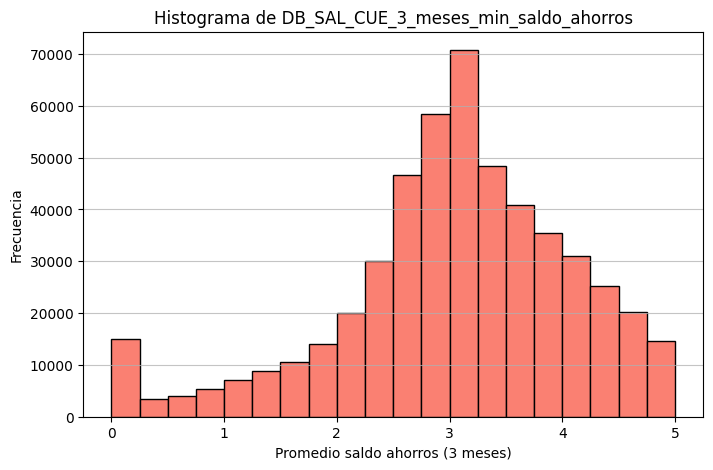

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_limpio['DB_SAL_CUE_3_meses_min_saldo_ahorros'].dropna(), 
         bins=20, color='salmon', edgecolor='black')
plt.title('Histograma de DB_SAL_CUE_3_meses_min_saldo_ahorros')
plt.xlabel('Promedio saldo ahorros (3 meses)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [20]:
df_limpio['target'].value_counts()

target
0    440871
1     44812
5      8064
4      6548
2      5632
3      3216
Name: count, dtype: int64

**AGRUPANDO POR CORRELACIÓN**

In [21]:
import pandas as pd

# === FUNCIÓN PARA AGRUPAR VARIABLES CORRELACIONADAS ===
def agrupar_por_correlacion(df, umbral=0.6):
    """
    Agrupa variables numéricas del DataFrame por correlación >= umbral.
    Retorna:
        - Una lista de sets con columnas correlacionadas.
        - Un set con columnas que no se agruparon (sin correlación suficiente).
    También imprime el progreso de cuántas columnas quedan por evaluar.
    """
    df_corr = df.corr().abs()
    columnas_restantes = set(df_corr.columns)
    grupos = []
    columnas_sin_agrupacion = set()

    while columnas_restantes:
        col = next(iter(columnas_restantes))
        
        # Buscar las columnas correlacionadas dentro de las restantes
        correladas = {c for c in columnas_restantes if df_corr.loc[col, c] >= umbral}
        
        if len(correladas) > 1:
            grupos.append(correladas)
            columnas_restantes -= correladas
            print(f"✅ Nuevo set creado ({len(correladas)} columnas): {correladas}")
            print(f"➡️  Columnas restantes: {len(columnas_restantes)}\n")
        else:
            # Guardar la columna sin agrupación
            columnas_sin_agrupacion.add(col)
            columnas_restantes.remove(col)
            print(f"⚪ Columna sin correlación suficiente: {col}")
            print(f"➡️  Columnas restantes: {len(columnas_restantes)}\n")

    return grupos, columnas_sin_agrupacion


# === APLICACIÓN DIRECTA AL DATAFRAME df_limpio ===
df_numerico = df_limpio.select_dtypes(include='number')
grupos_variables, columnas_sin_agrupacion = agrupar_por_correlacion(df_numerico, umbral=0.6)

# Mostrar resultados finales
print(f"\n🔹 Total de grupos encontrados: {len(grupos_variables)}\n")
for i, grupo in enumerate(grupos_variables, start=1):
    print(f"Set {i}, cantidad columnas: {len(grupo)}: {grupo}")

print(f"\n⚪ Total de columnas sin agrupación: {len(columnas_sin_agrupacion)}")
print(f"Columnas sin agrupación: {columnas_sin_agrupacion}")

✅ Nuevo set creado (44 columnas): {'DB_SAL_CUE_2_meses_max_saldo_ahorros', 'DB_SAL_CUE_11_meses_sum_saldo_ahorros', 'DB_SAL_CUE_2_meses_min_saldo_ahorros', 'DB_SAL_CUE_6_meses_sum_saldo_ahorros', 'DB_SAL_CUE_12_meses_max_saldo_ahorros', 'DB_SAL_CUE_6_meses_min_saldo_ahorros', 'DB_SAL_CUE_7_meses_min_saldo_ahorros', 'DB_SAL_CUE_11_meses_max_saldo_ahorros', 'DB_SAL_CUE_3_meses_max_saldo_ahorros', 'DB_SAL_CUE_12_meses_prom_saldo_ahorros', 'DB_SAL_CUE_10_meses_sum_saldo_ahorros', 'DB_SAL_CUE_4_meses_prom_saldo_ahorros', 'DB_SAL_CUE_9_meses_prom_saldo_ahorros', 'DB_SAL_CUE_3_meses_sum_saldo_ahorros', 'DB_SAL_CUE_2_meses_prom_saldo_ahorros', 'DB_SAL_CUE_7_meses_sum_saldo_ahorros', 'DB_SAL_CUE_11_meses_prom_saldo_ahorros', 'DB_SAL_CUE_7_meses_max_saldo_ahorros', 'DB_SAL_CUE_3_meses_min_saldo_ahorros', 'DB_SAL_CUE_5_meses_prom_saldo_ahorros', 'DB_SAL_CUE_5_meses_sum_saldo_ahorros', 'DB_SAL_CUE_4_meses_min_saldo_ahorros', 'DB_SAL_CUE_10_meses_max_saldo_ahorros', 'DB_SAL_CUE_3_meses_prom_saldo_a

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.multiclass import OneVsRestClassifier
import pandas as pd

target = 'target'  # tu variable objetivo
X_total = df_limpio
y_total = df_limpio[target]

# === SELECCIÓN DE TOP 1 VARIABLE POR AUC DE CADA GRUPO ===
variables_seleccionadas = set()
columnas_sin_agrupacion = set()  # si no estaba definido

for i, grupo in enumerate(grupos_variables, start=1):
    if len(grupo) == 1:
        # Si el grupo tiene solo una variable, no se evalúa, se pasa a sin agrupación
        var_unica = list(grupo)[0]
        columnas_sin_agrupacion.add(var_unica)
        print(f"\n⚪ Grupo {i} tiene una sola variable: {var_unica}, se agrega a sin agrupación")
        continue

    resultados = []
    for var in grupo:
        X = X_total[[var]]
        y = y_total
        try:
            model = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=500, class_weight='balanced'))
            model.fit(X, y)
            y_pred_prob = model.predict_proba(X)
            auc = roc_auc_score(y, y_pred_prob, multi_class='ovr')
            resultados.append((var, auc))
        except Exception as e:
            # Si algo falla, dejamos la variable como sin agrupación
            columnas_sin_agrupacion.add(var)
            print(f"⚠️ Error con variable {var}: {e}. Se agrega a sin agrupación")
            continue

    if resultados:
        resultados_df = pd.DataFrame(resultados, columns=['variable','AUC']).sort_values(by='AUC', ascending=False)
        top1 = resultados_df.iloc[0]['variable']
        variables_seleccionadas.add(top1)
        print(f"\n📌 Grupo {i}: {grupo}")
        print(f"Top 1 variable por AUC: {top1}")


# === COLUMNAS SIN AGRUPACION ===
print(f"\n⚪ Columnas sin agrupación: {columnas_sin_agrupacion}")

# === VARIABLES FINALES SELECCIONADAS ===
print(f"\n✅ Cantidad {len(variables_seleccionadas)} Variables seleccionadas (top 1 de cada grupo): {variables_seleccionadas}")


📌 Grupo 1: {'DB_SAL_CUE_2_meses_max_saldo_ahorros', 'DB_SAL_CUE_11_meses_sum_saldo_ahorros', 'DB_SAL_CUE_2_meses_min_saldo_ahorros', 'DB_SAL_CUE_6_meses_sum_saldo_ahorros', 'DB_SAL_CUE_12_meses_max_saldo_ahorros', 'DB_SAL_CUE_6_meses_min_saldo_ahorros', 'DB_SAL_CUE_7_meses_min_saldo_ahorros', 'DB_SAL_CUE_11_meses_max_saldo_ahorros', 'DB_SAL_CUE_3_meses_max_saldo_ahorros', 'DB_SAL_CUE_12_meses_prom_saldo_ahorros', 'DB_SAL_CUE_10_meses_sum_saldo_ahorros', 'DB_SAL_CUE_4_meses_prom_saldo_ahorros', 'DB_SAL_CUE_9_meses_prom_saldo_ahorros', 'DB_SAL_CUE_3_meses_sum_saldo_ahorros', 'DB_SAL_CUE_2_meses_prom_saldo_ahorros', 'DB_SAL_CUE_7_meses_sum_saldo_ahorros', 'DB_SAL_CUE_11_meses_prom_saldo_ahorros', 'DB_SAL_CUE_7_meses_max_saldo_ahorros', 'DB_SAL_CUE_3_meses_min_saldo_ahorros', 'DB_SAL_CUE_5_meses_prom_saldo_ahorros', 'DB_SAL_CUE_5_meses_sum_saldo_ahorros', 'DB_SAL_CUE_4_meses_min_saldo_ahorros', 'DB_SAL_CUE_10_meses_max_saldo_ahorros', 'DB_SAL_CUE_3_meses_prom_saldo_ahorros', 'DB_SAL_CUE_1

In [23]:
df_limpio['target'].value_counts()

target
0    440871
1     44812
5      8064
4      6548
2      5632
3      3216
Name: count, dtype: int64

In [24]:
variables_seleccionadas

{'DB_CLI_der_edad_anios_exp',
 'DB_CLI_der_ingreso_nomina_ratio',
 'DB_CLI_ingreso',
 'DB_CLI_num_ofertas',
 'DB_CLI_num_productos',
 'DB_SAL_CUE_3_meses_min_saldo_ahorros',
 'DB_SAL_CUE_cv_3m_ahorros',
 'DB_SAL_CUE_ratio_ahorros_otros'}

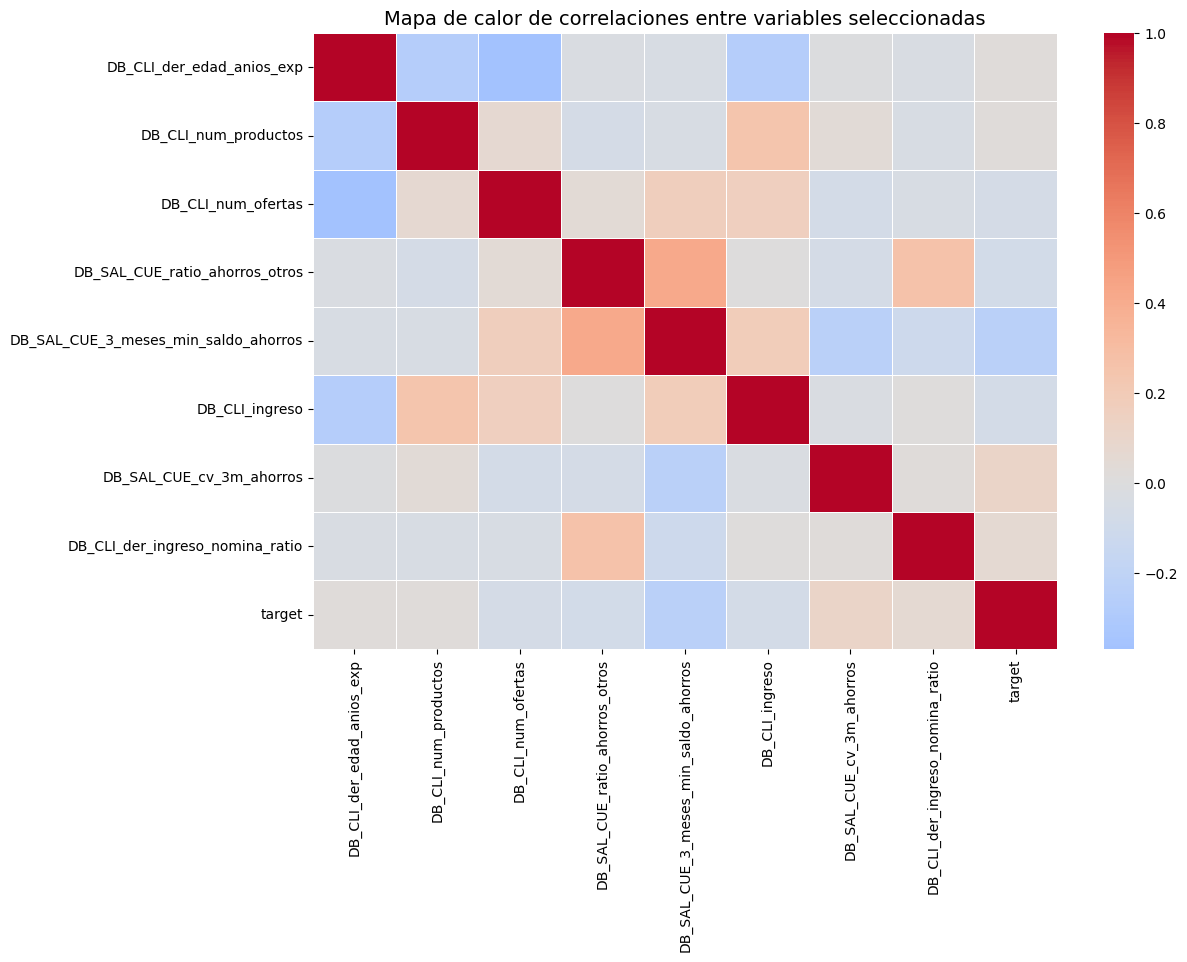

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supongamos que tienes tu DataFrame principal
# df_limpio = ...  # DataFrame con todas las variables

# Lista de variables seleccionadas
features = list(variables_seleccionadas) + ['target'] 

# Subconjunto del DataFrame solo con esas variables
df_subset = df_limpio[features]

# Calcular la matriz de correlación
corr_matrix = df_subset.corr()

# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 8))

# Dibujar el heatmap
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,   # pon True si quieres mostrar los valores
    center=0,
    linewidths=0.5
)

plt.title("Mapa de calor de correlaciones entre variables seleccionadas", fontsize=14)
plt.show()

In [26]:
features = list(variables_seleccionadas) + ['target'] + ['periodo']

In [27]:
df_save = df_limpio[features]

In [28]:
nombre_archivo = 'df_final.csv'
df_save.to_csv(nombre_archivo, index=False)

print(f"DataFrame exportado exitosamente a: {nombre_archivo}")
print(f"Dimensiones del archivo final: {df_save.shape}")

DataFrame exportado exitosamente a: df_final.csv
Dimensiones del archivo final: (509143, 10)


In [29]:
df_save.head()

,DB_CLI_der_edad_anios_exp,DB_CLI_num_productos,DB_CLI_num_ofertas,DB_SAL_CUE_ratio_ahorros_otros,DB_SAL_CUE_3_meses_min_saldo_ahorros,DB_CLI_ingreso,DB_SAL_CUE_cv_3m_ahorros,DB_CLI_der_ingreso_nomina_ratio,target,periodo
0,3.849800,1,0,3175400.0,2.6140,4.6527,0.252333,0.823093,0,period_5
1,0.862268,1,0,3225400.0,3.2254,4.2447,0.000844,0.809331,0,period_5
2,4.360000,1,0,2753000.0,2.7090,4.2117,0.001410,0.808124,0,period_5
3,4.391400,1,2,3751100.0,3.7511,4.1584,0.006208,0.806141,0,period_5
4,4.307700,1,0,3408600.0,3.1789,4.3285,0.045243,0.812330,0,period_5
